In [1]:
import json
import os
import subprocess
import time
import math
from typing import List, Optional
from common import *
from experiment import NetworkSetting
from data.media import MediaExperiment
from treatments.media import treatment_map
from treatments.network_settings import *

# Collect Data

In [2]:
LABELS = [
    'baseline',
    #'iblt_delay110',
    #'iblt_delay110_hint',
    f'iblt_delay{ACK_DELAY_WIFI}_hint_nack',
    f'iblt_delay{ACK_DELAY_CELL}_hint_nack',
    f'iblt_delay{ACK_DELAY_SAT}_hint_nack',
    'baseline_rtunnel_retx7',
    'baseline_rtunnel_retx7_ordered32',
]
DURATION = 180

network_settings_ = network_settings([10])

In [3]:
# data packet every 20 ms
def collect_data(duration=DURATION, labels=LABELS, network_setting=network_settings_['wifi'], execute=False):
    treatments = [treatment_map(label) for label in labels]
    exp = MediaExperiment(duration, treatments, network_setting)
    data = exp.to_raw_data(execute=execute)
    results = data.data
    return results

In [4]:
# check results
def check_media_output(output):
    assert isinstance(output.get('client_latencies'), list)
    assert len(output['client_latencies']) > 0
    assert isinstance(output.get('server_latencies'), list)
    # assert len(output['server_latencies']) > 0
    assert isinstance(output.get('client_num_spurious'), int)

labels_cell = [l for l in LABELS if ('iblt' not in l or str(ACK_DELAY_CELL) in l)]
RESULTS_CELL = collect_data(execute=True, labels=labels_cell, network_setting=network_settings_['cellular'][0])
labels_wifi = [l for l in LABELS if ('iblt' not in l or str(ACK_DELAY_WIFI) in l)]
RESULTS_WIFI = collect_data(execute=True, labels=labels_wifi, network_setting=network_settings_['wifi'][0])
labels_sat = [l for l in LABELS if ('iblt' not in l or str(ACK_DELAY_SAT) in l)]
RESULTS_SAT = collect_data(execute=True, labels=labels_sat, network_setting=network_settings_['sat'][0])
RESULTS_SAT_LONG = collect_data(execute=True, labels=labels_sat, network_setting=network_settings_['sat_long'][0])
RESULTS_SAT_LONG_LONG = collect_data(execute=True, labels=labels_sat, network_setting=network_settings_['sat_long_long'][0])

# Plot CDF Data

### Plotting functions

In [5]:
def preprocess_latencies(latencies, num_ticks=100):
    ticks = []
    latencies.sort()
    for i in range(num_ticks):
        index = int(i * len(latencies) / num_ticks)
        ticks.append(latencies[index])
    ticks.append(latencies[-1])
    # Convert ns to ms
    return [tick / 1000000.0 for tick in ticks]

In [6]:
def parse_and_plot_delay_cdf(keys, results, one_way_delay, style=False, xlabel='De-Jitter Latency (ms)', xlim=0, labels=None, min_pct=86, client=True, title='Client De-Jitter Latencies', pdf=None):
    client_results = {}
    server_results = {}
    for key in keys:
        if key not in results: 
            print(f'missing {key}')
            continue
        result = results[key]
        client_results[key] = result.get('client_latencies')
        server_results[key] = result.get('server_latencies')
    if client:
        plot_results = client_results
    else:
        plot_results = server_results
    plot_delay_cdf(plot_results, keys, style=style, one_way_delay=one_way_delay, xlabel=xlabel, xlim=xlim, min_pct=min_pct, title=title, pdf=pdf)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Optional
import math

def plot_delay_cdf(results, keys: List[str], xlabel: str, one_way_delay, style=False, min_pct=0, xlim=0, title=None, num_ticks=1000, pdf: Optional[str]=None):
    plt.figure(figsize=(6, 3))

    labels = []
    for key in keys:
        if key not in results:
            print(f'Skipping {key}')
            continue
        data = results[key]
        data = preprocess_latencies(data, num_ticks=num_ticks)
        data = [x + one_way_delay for x in data]
        if sum(data) == 0:
            print('all zeroes!', key)
        ys = [i / len(data) for i in range(1, len(data)+1)]  # 0 to 1
        ys_log = [-math.log10(1 - y) if y < 1 else np.nan for y in ys]  # Avoid log(0)

        # Make it steps
        xs_new = [data[0]]
        ys_new = []
        for i in range(0, len(data)-1):
            xs_new.append(data[i+1])
            xs_new.append(data[i+1])
            ys_new.append(ys_log[i])
            ys_new.append(ys_log[i])
        xs_new.append(data[-1])
        ys_new.append(ys_log[-1])
        ys_new.append(ys_log[-1])
        if style:
            label = LABEL_MAP[key]
            sty = STYLE[label]
            if label == 'Packrat':
                print(len(xs_new))
                markevery = [0, 1440, 1815, 1945, 1980, 1982, 1983, 1985, 1996, 1997, 1998, 1999]
                plt.plot(xs_new, ys_new, label=label, marker=sty.marker, markevery=markevery, markersize=sty.markersize, color=sty.color, linestyle=sty.linestyle, linewidth=2)
            else:
                plt.plot(xs_new, ys_new, label=label, color=sty.color, linestyle=sty.linestyle, linewidth=2)
        else:
            label = key
            plt.plot(xs_new, ys_new, label=label)
        labels.append(label)

    plt.xlabel(xlabel)
    plt.xlim(xlim)

    # Custom Y-axis: -log10(1 - y), show original percentile as label
    tick_vals_with_labels = [0.1, 0.9, 0.99, 0.999]
    tick_vals = [0.1 * i for i in range(1, 10, 2)]
    tick_vals += [0.9 + 0.01 * i for i in range(1, 10, 2)]
    tick_vals += [0.99 + 0.001 * i for i in range(1, 10, 2)]
    ytick_locs = [-np.log10(1 - y) for y in tick_vals]
    ytick_labels = []
    for y in tick_vals:
        if y in tick_vals_with_labels:
            ytick_labels.append(f'{int(y * 10000)/100:.1f}%')
        else:
            ytick_labels.append('')

    plt.yticks(ticks=ytick_locs, labels=ytick_labels)
    plt.ylabel('Percentile')
    plt.grid(alpha=0.4)

    plot_title_and_legend(title, labels, ncol=2, base_height=1.2, row_height=0.06, title_height=0.08)

    if pdf:
        save_pdf(pdf)

    plt.show()


# Main Benchmarks

2002
../figures/media_benchmark_sat.pdf


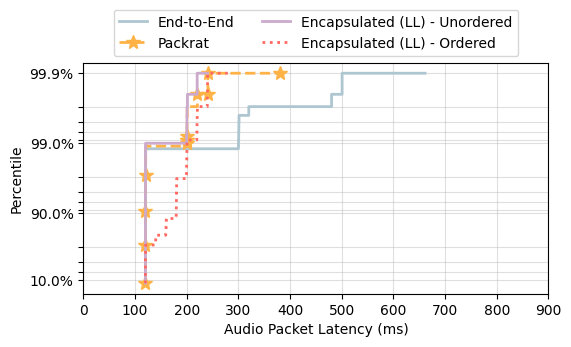

In [13]:
results = RESULTS_SAT
keys = labels_sat
ns = network_settings_['sat'][0]
xlabel = 'Audio Packet Latency (ms)' # time_received - time_produced
title=None #ns.label()
frame_length = 40 #ms
parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2') + frame_length, xlabel=xlabel,
                         style=True, client=True, title=title, xlim=(0, 900), pdf='../figures/media_benchmark_sat.pdf')

2002
../figures/media_benchmark_sat_long_long.pdf


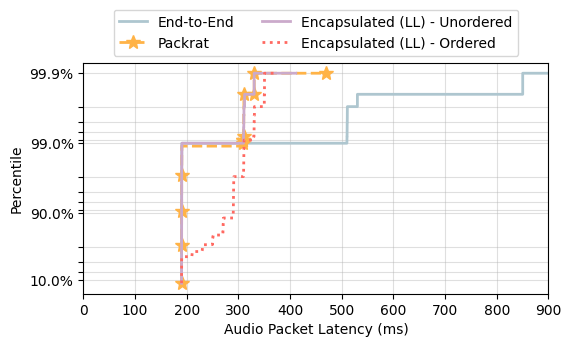

In [8]:
results = RESULTS_SAT_LONG_LONG
keys = labels_sat
ns = network_settings_['sat_long_long'][0]
xlabel = 'Audio Packet Latency (ms)' # time_received - time_produced
title=None #ns.label()
frame_length = 40 #ms
parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2') + frame_length, xlabel=xlabel,
                         style=True, client=True, title=title, xlim=(0, 900), pdf='../figures/media_benchmark_sat_long_long.pdf')

2002
../figures/media_benchmark_sat_long.pdf


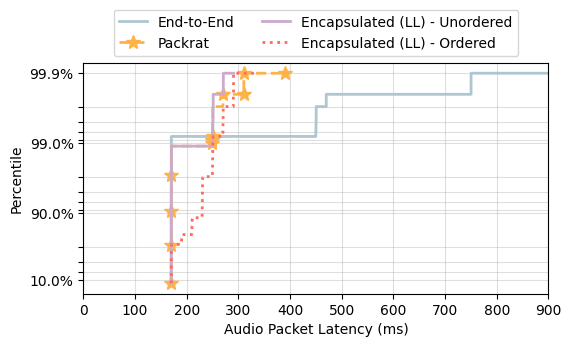

In [9]:
results = RESULTS_SAT_LONG
keys = labels_sat
ns = network_settings_['sat_long'][0]
xlabel = 'Audio Packet Latency (ms)' # time_received - time_produced
title=None #ns.label()
frame_length = 40 #ms
parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2') + frame_length, xlabel=xlabel,
                         style=True, client=True, title=title, xlim=(0, 900), pdf='../figures/media_benchmark_sat_long.pdf')

2002
../figures/media_benchmark_cell.pdf


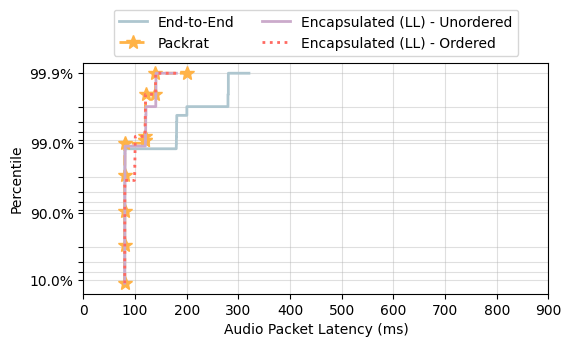

In [11]:
results = RESULTS_CELL
keys = [l for l in LABELS if ('iblt' not in l or str(ACK_DELAY_CELL) in l)]
ns = network_settings_['cellular'][0]
xlabel = 'Audio Packet Latency (ms)' # time_received - time_produced
title=None #ns.label()
frame_length = 40 #ms
parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2') + frame_length, xlabel=xlabel,
                         style=True, client=True, title=title, xlim=(0, 900), pdf='../figures/media_benchmark_cell.pdf')

# end-to-end stalls for 2*(delay1+delay2), 1% of the time
# sidekick stalls for 2*delay1, 1% of the time
# ordere wifi like 30% of the packets stall (more than 20ms, it's like a glitch)

2002
../figures/media_benchmark_wifi.pdf


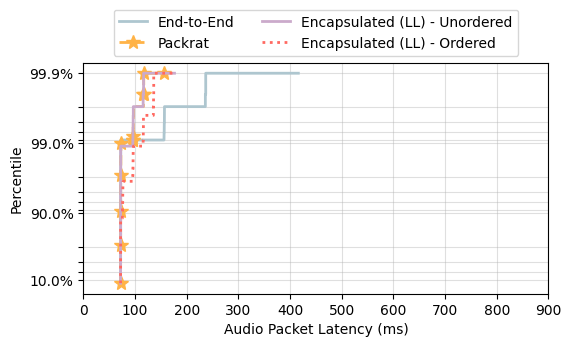

In [12]:
results = RESULTS_WIFI
keys = [l for l in LABELS if ('iblt' not in l or str(ACK_DELAY_WIFI) in l)]
ns = network_settings_['wifi'][0]
xlabel = 'Audio Packet Latency (ms)' # time_received - time_produced
title=None #ns.label()
frame_length = 40 #ms
parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2') + frame_length, xlabel=xlabel,
                         style=True, client=True, title=title, xlim=(0, 900), pdf='../figures/media_benchmark_wifi.pdf')

# No FEC

../figures/media_benchmark.pdf


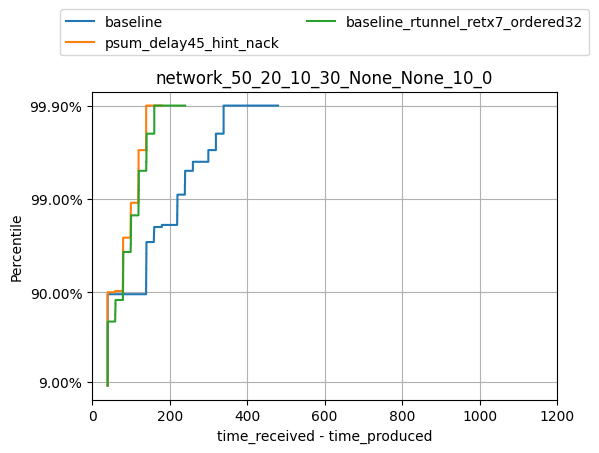

../figures/media_benchmark.pdf


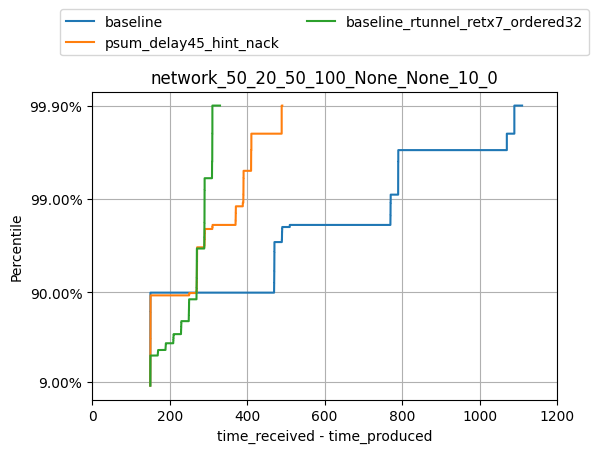

In [181]:
# No FEC
keys = [
    'baseline',
    'psum_delay45_hint_nack',
    # 'iblt_delay45_hint_nack',
    # 'baseline_rtunnel_retx7',
    'baseline_rtunnel_retx7_ordered32',
]
network_settings = [
    NetworkSetting(bw1=50, bw2=20, delay1=10, delay2=30, loss1=10, loss2=0),
    NetworkSetting(bw1=50, bw2=20, delay1=50, delay2=100, loss1=10, loss2=0),
]
for ns in network_settings:
    results = collect_data(labels=keys, duration=30, network_setting=ns, execute=True)
    figure_labels = None
    xlabel = 'time_received - time_produced'
    parse_and_plot_delay_cdf(keys, results, one_way_delay=ns.get('delay1') + ns.get('delay2'), xlabel=xlabel, xlim=(0,1200),
                             labels=figure_labels, client=True, title=ns.label())

# Archive

../figures/media_benchmark.pdf


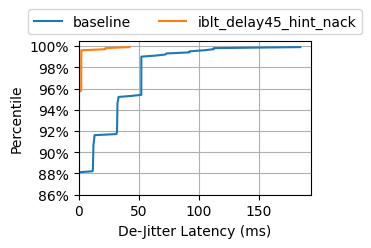

In [9]:
# 1. Sidekick improves the 99th percentile de-jitter buffer latency over the baseline.
keys = [
    'baseline',
    # 'psum_delay45_hint_nack',
    'iblt_delay45_hint_nack',
]
# figure_labels = ['Baseline', 'Sidekick']
figure_labels = None
results = collect_data(keys)
parse_and_plot_delay_cdf(keys, results, labels=figure_labels, client=True, title=None, pdf='../figures/media_benchmark.pdf')

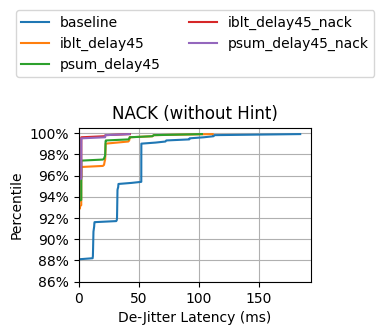

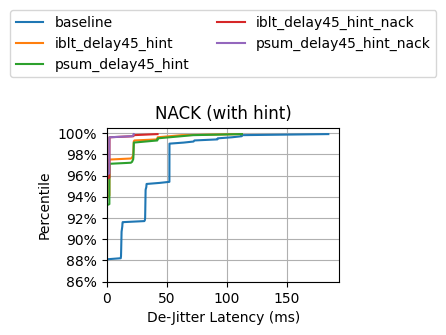

In [13]:
# 2. Sending with nack reduces tx_packets (keeps perf).
parse_and_plot_delay_cdf(['baseline', 'iblt_delay45', 'psum_delay45', 'iblt_delay45_nack', 'psum_delay45_nack'], client=True, title='NACK (without Hint)')
parse_and_plot_delay_cdf(['baseline', 'iblt_delay45_hint', 'psum_delay45_hint', 'iblt_delay45_hint_nack', 'psum_delay45_hint_nack'], client=True, title='NACK (with hint)')

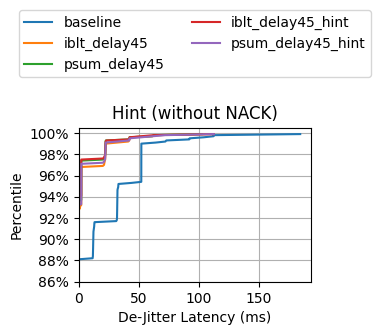

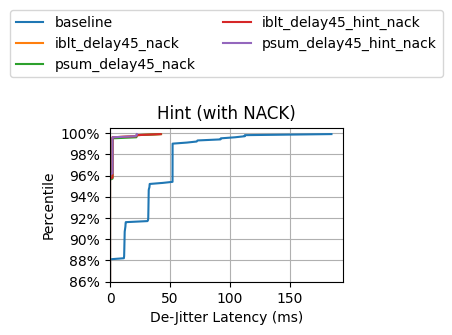

In [14]:
# 3. Sending with hint reduces tx_bytes (keeps perf).
parse_and_plot_delay_cdf(['baseline', 'iblt_delay45', 'psum_delay45', 'iblt_delay45_hint', 'psum_delay45_hint'], client=True, title='Hint (without NACK)')
parse_and_plot_delay_cdf(['baseline', 'iblt_delay45_nack', 'psum_delay45_nack', 'iblt_delay45_hint_nack', 'psum_delay45_hint_nack'], client=True, title='Hint (with NACK)')

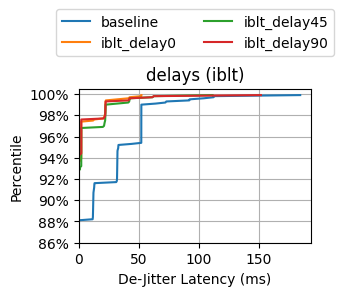

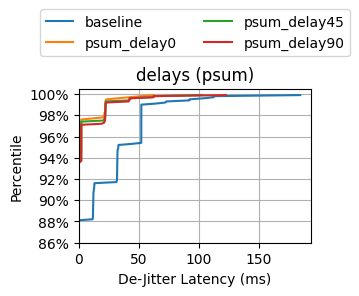

In [15]:
# 4. Sending with delay reduces spurious retx (keeps or improves perf).
def gen_labels(ty):
    labels = ['baseline']
    for delay in [0, 45, 90]:
        labels.append(f'{ty}_delay{delay}')
    return labels

parse_and_plot_delay_cdf(gen_labels('iblt'), client=True, title='delays (iblt)')
parse_and_plot_delay_cdf(gen_labels('psum'), client=True, title='delays (psum)')

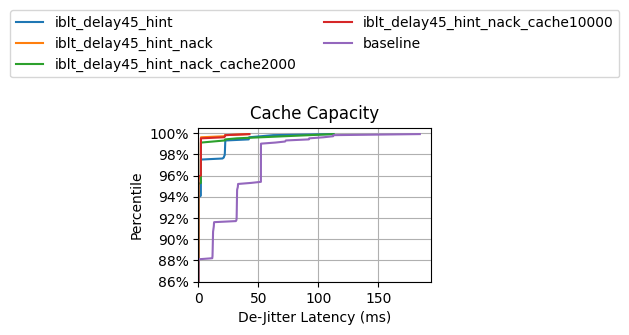

In [11]:
# 5. The optimistic cache policy reduces the cache size (keeps perf).
labels = [
    'iblt_delay45_hint',
    'iblt_delay45_hint_nack',
    'iblt_delay45_hint_nack_cache2000',
    'iblt_delay45_hint_nack_cache10000',
    'baseline',
]
parse_and_plot_delay_cdf(labels, client=True, title='Cache Capacity')

../figures/media_benchmark.pdf


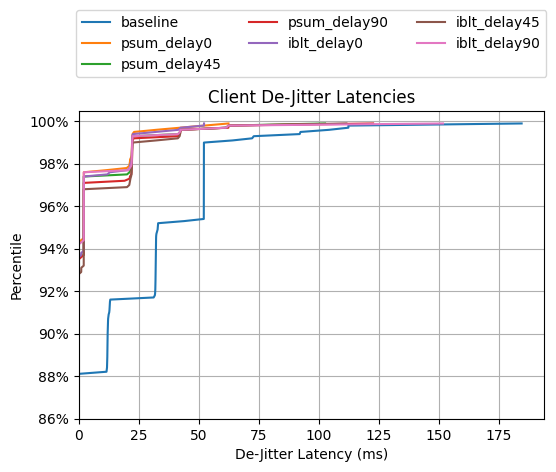

../figures/media_benchmark.pdf


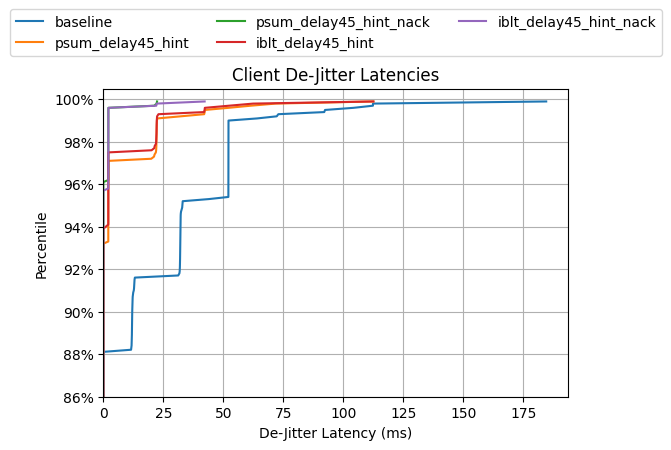

../figures/media_benchmark.pdf


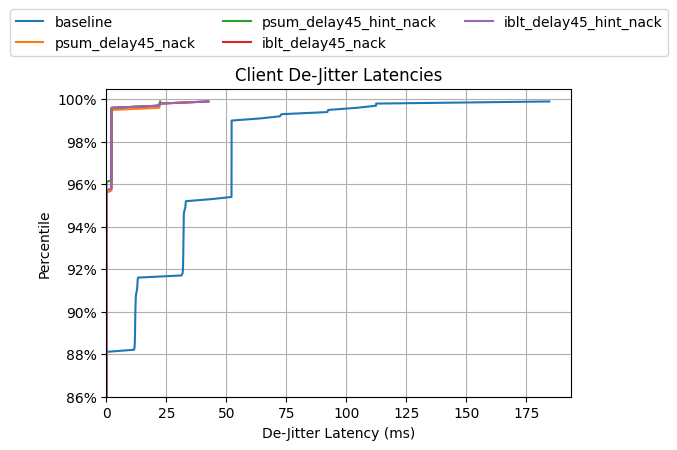

In [51]:
parse_and_plot_delay_cdf(list(filter(lambda x: 'hint' not in x and 'nack' not in x, labels)), client=True)
parse_and_plot_delay_cdf(['baseline'] + list(filter(lambda x: 'hint' in x, labels)), client=True)
parse_and_plot_delay_cdf(['baseline'] + list(filter(lambda x: 'nack' in x, labels)), client=True)

# Plot network statistics

### Plotting functions

In [11]:
def plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets'):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        ifaces = results[label]['statistics']['ifaces']
        data = results[label]['statistics'][statistic]
        assert len(data) == len(ifaces)
        x = np.arange(len(ifaces))
        plt.bar(x + i * width, data, width=width, label=label)

    plt.xlabel('Network Interface')
    plt.ylabel(statistic)
    plt.xticks(np.arange(len(ifaces)), ifaces)
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=3)
    plt.show()

### Execute

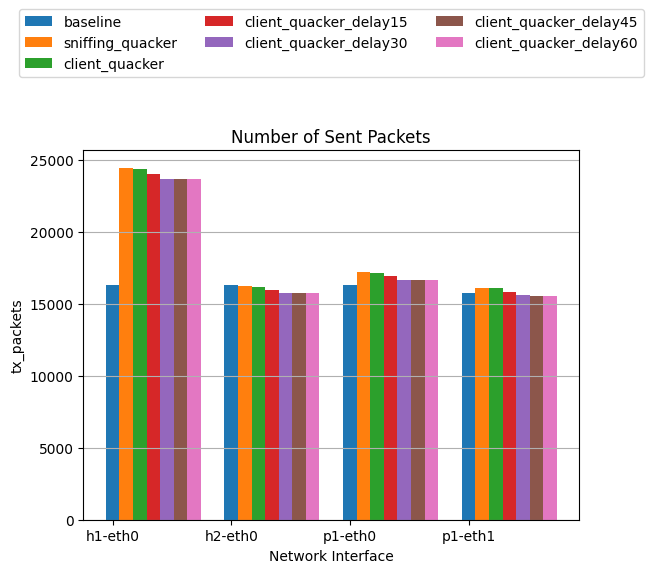

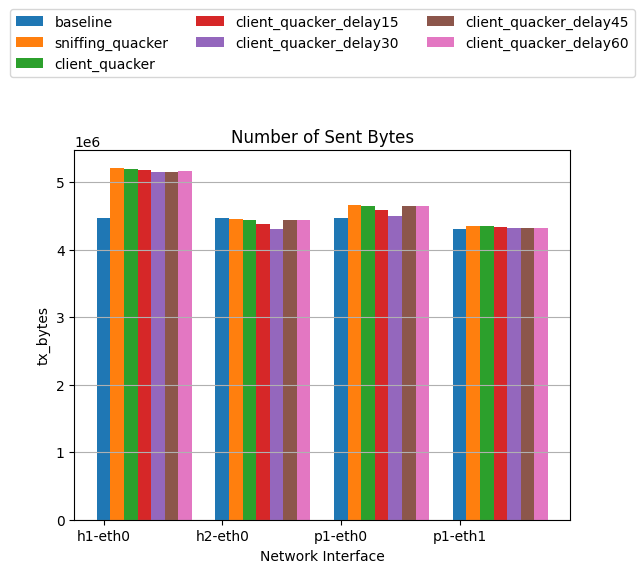

In [12]:
plot_network_statistic(labels, results, title='Number of Sent Packets', statistic='tx_packets')
plot_network_statistic(labels, results, title='Number of Sent Bytes', statistic='tx_bytes')

# Plot num spurious

In [13]:
def plot_num_spurious(labels, results, title='Number Spurious Received'):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        num_spurious = results[label]['client_num_spurious']
        plt.bar([i * width], num_spurious, width=width, label=label)

    plt.ylabel('Num Spurious Received')
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
    plt.show()

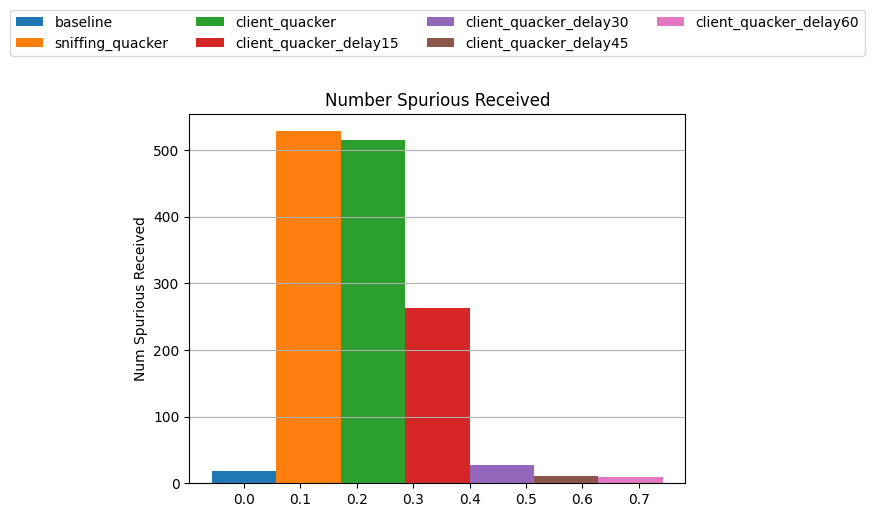

In [14]:
plot_num_spurious(labels, results)